# Excercise 2


Nguyễn Hải Đăng - 23127165

---

## *Hoeffding Inequality*

### Experiment Setup

* Conduct an experiment with **1,000 coins**, each flipped **10 times independently**.
* Focus on three specific coins:

  * **$c_1$**: the **first** coin flipped.
  * **$c_{\text{rand}}$**: a **randomly selected** coin among the 1,000.
  * **$c_{\text{min}}$**: the coin with the **lowest frequency of heads** (if multiple coins tie, select the one appearing **earlier**).
* Let **$v_1$**, **$v_{\text{rand}}$**, and **$v_{\text{min}}$** denote the **fractions of heads** obtained for these three coins, respectively, across their 10 flips.

The experiment will be **run 100,000 times** to obtain the **empirical distributions** of $v_1$, $v_{\text{rand}}$, and $v_{\text{min}}$.


## **Question 1 & 2:**

We apply **Hoeffding’s Inequality** to analyze this problem:

$$
P(|E_{in} - E_{out}| > \epsilon) \leq 2e^{-2\epsilon^2 N}
$$

Given the small sample size, random fluctuations can significantly affect the results. Therefore, we select a relatively large tolerance value ($\epsilon = 0.3$) to obtain a more meaningful probabilistic bound.

Since each coin flip represents an independent Bernoulli trial with probability (p = 0.5), and the experiment involves a large number of coins, the out-of-sample error ($E_{out}$) is expected to converge to 0.5 as the number of trials increases.


In [1]:
import numpy as np

# Parameters
N_COINS = 1000          # number of coins
N_FLIPS = 10            # number of flips per coin
N_EXPERIMENTS = 100000  # number of repeated experiments

# Hoeffding parameters
EPSILON = 0.3
E_OUT = 0.5
hoeffding_bound = 2 * np.exp(-2 * N_FLIPS * EPSILON**2)

In [2]:
def run_experiment():
    """
    Simulate flipping 1000 coins 10 times each.
    Return v1, vrand, and vmin (fractions of heads for each selected coin)
    """
    flips = np.random.randint(2, size=(N_COINS, N_FLIPS))  # 0: tails, 1: heads
    heads_frac = np.mean(flips, axis=1)

    v1 = heads_frac[0]
    v_rand = heads_frac[np.random.randint(N_COINS)]
    v_min = np.min(heads_frac)

    return np.array([v1, v_rand, v_min])


In [3]:
# Run all experiments
v = np.array([run_experiment() for _ in range(N_EXPERIMENTS)])
E_IN = np.mean(v, axis=0)

# Results
v1_mean, vrand_mean, vmin_mean = E_IN
print("\n\tAverage Value:")
print(f"Average v1   = {v1_mean}")
print(f"Average vrand = {vrand_mean}")
print(f"Average vmin  = {vmin_mean}")

# Check Hoeffding Inequality for each coin
p = np.abs(v - E_OUT) > EPSILON
violations = np.mean(p, axis=0)

print("\n\tHoeffding bound:", hoeffding_bound)
print(f"Violation probability (c1):     {violations[0]}")
print(f"Violation probability (crand):  {violations[1]}")
print(f"Violation probability (cmin):   {violations[2]}")

print("\n\tSatisfies Hoeffding inequality:")
print("c1:", violations[0] < hoeffding_bound)
print("crand:", violations[1] < hoeffding_bound)
print("cmin:", violations[2] < hoeffding_bound)


	Average Value:
Average v1   = 0.5010069999999964
Average vrand = 0.49991200000000674
Average vmin  = 0.03785199999997653

	Hoeffding bound: 0.3305977764431731
Violation probability (c1):     0.06564
Violation probability (crand):  0.06591
Violation probability (cmin):   0.99998

	Satisfies Hoeffding inequality:
c1: True
crand: True
cmin: False


**Question 1**: 
=> The average value of $v_{min}$ is closet to: **[b] 0.01**

**Question 2**: 
=> The correct answer is: **[d] $c_1 \text{ and } c_{rand}$**

---

## *Error and Noise*

In this setting, we consider two binary functions:

* $f$: the **target function**, representing the true underlying relationship.
* $h$: the **hypothesis function**, which attempts to approximate $f$.

The hypothesis $h$ may not perfectly match $f$. We assume that $h$ makes an error with probability $\mu$. Therefore, for any input $\mathbf{x}$:

* $h(x) = f(x)$ with probability $1 - \mu$

* $h(x) \neq f(x)$ with probability $\mu$

To model noise in the target function, we define a **noisy version of $f$**.
The observed label $y$ is a potentially corrupted version of $f(\mathbf{x})$, described by:

* $P(y \mid \mathbf{x}) = 
\begin{cases} 
      \lambda & y = f(x) \\
      1 - \lambda & y \neq f(x) 
\end{cases}$

Here, $\lambda$ represents the probability that the observed label $y$ matches the true target value $f(\mathbf{x})$, while $1 - \lambda$ denotes the **noise rate** — the probability that the label is flipped.


## **Question 3:**

The probability that the hypothesis $h$ makes an error in approximating the observed label $y$ can be derived by considering two mutually exclusive cases:

1. $h(x) = f(x)$ but $y \neq f(x)$: this occurs when $h$ is correct, but the label is corrupted by noise.
2. $h(x) \neq f(x)$ but $y = f(x)$: this occurs when $h$ is wrong, but the noise flips the label back to the correct value.

Combining both cases, the total probability of error is given by:

$$
P(\text{error}) = (1 - \mu)(1 - \lambda) + \mu \lambda
$$

where:

* $\mu$ is the probability that $h$ disagrees with $f$ (hypothesis error),
* $\lambda$ is the probability that the observed label $y$ matches the true label $f(x)$.


=> The correct answer is: **[e] $P(\text{error}) = (1 - \lambda)(1 - \mu) + \lambda \mu$**


## **Question 4:**

From the previous result, we have:

$$
P(\text{error}) = (1 - \lambda)(1 - \mu) + \lambda \mu = 1 - \mu - \lambda + 2\lambda\mu
$$

Substituting $\lambda = \frac{1}{2}$ into the above equation gives:

$$
P(\text{error}) = 1 - \mu - \frac{1}{2} + 2 \times \mu \times \frac{1}{2} = 1 - \mu - \frac{1}{2} + \mu = \frac{1}{2}
$$

This shows that when $\lambda = \frac{1}{2}$ (i.e., the noise completely randomizes the labels),
the performance of the hypothesis $h$ becomes **independent of $\mu$**.
In other words, no matter how good or bad $h$ is, the probability of making an error is always 0.5.

=> The correct answer is: **[b] $P(\text{error}) = 0.5$**

---

## *Linear Regression*

### *Experiment Setup*

* **Input Space:**
  The input domain is defined as:
  $$
  X = [-1, 1] \times [-1, 1]
  $$
  Points are uniformly sampled from this region.

* **Target Function ($f$):**
  In each run, a **random line** serves as the target function ( f ).
  This line is obtained by randomly selecting **two points** within the square $[-1, 1] \times [-1, 1]$ and taking the line passing through them.

  The line divides the plane into two regions:

  * Points on one side are labeled **+1**
  * Points on the other side are labeled **−1**

* **Data Generation ($D$):**
  A training dataset $D$ is generated by drawing random 2D points $x_n \in X$.
  Each point is assigned a label $y_n = \text{sign}(f(x_n))$, where $f$ is the target function.

---

### *Linear Regression Classification*

Below is the implementation of Linear Regression used to approximate the target function.

In [4]:
def generate_target_w():
    """Generate a random line (target function) from two random points in [-1, 1] x [-1, 1]."""
    p1 = np.random.uniform(-1, 1, 2)
    p2 = np.random.uniform(-1, 1, 2)
    target_w = np.array([
        p1[1]*p2[0] - p1[0]*p2[1],
        p2[1] - p1[1],
        p1[0] - p2[0]
    ]).reshape(-1, 1)
    return target_w, p1, p2

def generate_data(N, target_w):
    """Generate N random data points and assign labels according to target_w."""
    X = np.random.uniform(-1, 1, (N, 2))
    X = np.hstack((np.ones((N, 1)), X))
    y = np.sign(X @ target_w)
    return X, y

def train_linreg(X, y):
    """Compute linear regression weights using the pseudoinverse."""
    return np.linalg.pinv(X.T @ X) @ X.T @ y

def compute_output(X, w):
    """Compute predictions using the learned weights."""
    return np.sign(X @ w)

#### *Visualization Example*

A sample run is visualized below, showing:

* The target line ( f(x) )
* The hypothesis ( g(x) ) obtained by Linear Regression
* The training points colored by label (+1 in red, −1 in blue)

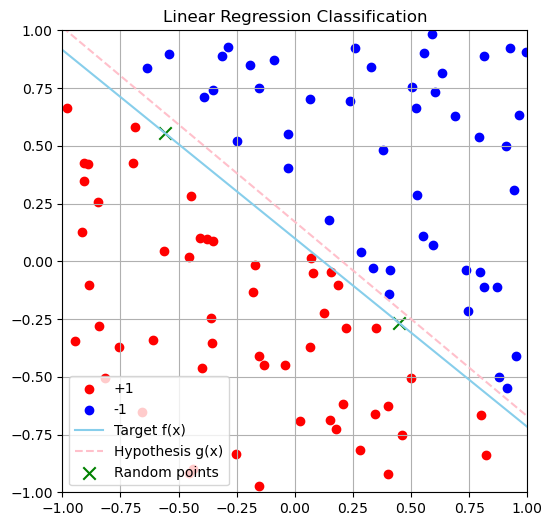

In [5]:
import matplotlib.pyplot as plt

N = 100
target_w, A, B = generate_target_w()
X, y = generate_data(N, target_w)

# Train linear regression
w_lr = train_linreg(X, y)
y_pred = compute_output(X, w_lr)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(X[y.flatten() == 1, 1], X[y.flatten() == 1, 2], color='red', label='+1')
plt.scatter(X[y.flatten() == -1, 1], X[y.flatten() == -1, 2], color='blue', label='-1')

# Target line
x_vals = np.array([-1, 1])
y_vals_target = -(target_w[0] + target_w[1]*x_vals) / target_w[2]
plt.plot(x_vals, y_vals_target, color='skyblue', label='Target f(x)')

# Hypothesis line
y_vals_hyp = -(w_lr[0] + w_lr[1]*x_vals) / w_lr[2]
plt.plot(x_vals, y_vals_hyp, color='pink', linestyle='--', label='Hypothesis g(x)')

plt.scatter([A[0], B[0]], [A[1], B[1]], color='green', marker='x', s=80, label='Random points')
plt.title("Linear Regression Classification")
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.legend()
plt.grid(True)
plt.show()


---

## **Question 5 & 6: Estimating $E_{in}$ and $E_{out}$**

To evaluate model performance:

* ( N = 100 )
* Each experiment is repeated **1000 times**
* For each run:

  * Compute **in-sample error**:
    [
    E_{in} = \frac{1}{N} \sum_{n=1}^{N} [g(x_n) \neq f(x_n)]
    ]
  * Compute **out-of-sample error** using another fresh set of 100 test points.

In [6]:
N_RUNS = 1000
E_in_total, E_out_total = 0, 0

for _ in range(N_RUNS):
    target_w, _, _ = generate_target_w()
    X_train, y_train = generate_data(100, target_w)
    w_lr = train_linreg(X_train, y_train)

    # In-sample
    y_pred_in = compute_output(X_train, w_lr)
    E_in = np.mean(y_pred_in != y_train)

    # Out-of-sample
    X_test, y_test = generate_data(100, target_w)
    y_pred_out = compute_output(X_test, w_lr)
    E_out = np.mean(y_pred_out != y_test)

    E_in_total += E_in
    E_out_total += E_out

print(f"Average Ein: {E_in_total / N_RUNS}")
print(f"Average Eout: {E_out_total / N_RUNS}")

Average Ein: 0.03886999999999999
Average Eout: 0.04835000000000006


**Question 5**: 
=> The closest value of the average $E_{in}$ is: **[c] 0.01**

**Question 6**: 
=> The closest value of the average $E_{out}$ is: **[c] 0.01**

---


## **Question 7 - PLA initialized with Linear Regression**

After computing the Linear Regression weights, we use them as the **initial weight vector** for the **Perceptron Learning Algorithm (PLA)**.
PLA iteratively updates the weights until all points are correctly classified.

### *Experiment Setup*

| Parameter          | Description                                                  |
| ------------------ | ------------------------------------------------------------ |
| Input space        | $ X = [-1,1] \times [-1,1] $                                 |
| Target function    | Random line through two random points                        |
| Number of samples  | $ N = 10 $                                                   |
| Initialization     | PLA starts from weights found by Linear Regression           |
| Update rule        | $ w(t+1) = w(t) + y_i x_i $ for a random misclassified point |
| Stopping criterion | All points correctly classified                              |
| Repetitions        | 1000 runs to compute average iterations                      |


In [7]:
def run_PLA(X, Y, w_init=None):
    """Run the Perceptron Learning Algorithm until convergence."""
    if w_init is None:
        w = np.zeros((X.shape[1], 1))
    else:
        w = w_init.copy()

    num_iterations = 0
    while True:
        y_pred = np.sign(X @ w)
        misclassified = np.where(y_pred.flatten() != Y.flatten())[0]

        if len(misclassified) == 0:
            break

        i = np.random.choice(misclassified)
        w += Y[i] * X[i].reshape(-1, 1)
        num_iterations += 1

    return w, num_iterations

In [8]:
num_runs = 1000
avg_iterations = 0

for _ in range(num_runs):
    target_w, _, _ = generate_target_w()
    X, y = generate_data(10, target_w)
    w_lin = train_linreg(X, y)
    _, n_iter = run_PLA(X, y, w_init=w_lin)
    avg_iterations += n_iter / num_runs

print(f"Average PLA iterations: {avg_iterations}")

Average PLA iterations: 3.4469999999999907


**Question 7**: 
=> The closest value is: **[a] 1**

---

## *Nonlinear Transformation*

### *Objective*

We investigate how **nonlinear feature transformations** can improve linear regression’s ability to classify data when the true decision boundary is nonlinear.

---

### *Target Function*

The target function is defined as:
$
f(x_1, x_2) = \operatorname{sign}(x_1^2 + x_2^2 - 0.6)
$
This function separates the input space into two regions:

* Points **inside** the circle $x_1^2 + x_2^2 = 0.6$ -> label = −1
* Points **outside** the circle -> label = +1

---

### *Data Generation*

We sample $N = 1000$ points uniformly from $[-1,1]\times[-1,1]$.
To simulate real-world noise, we randomly flip the sign of **10%** of the labels.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data using f(x1, x2)
def generate_data(N):
    X = np.random.uniform(-1, 1, (N, 2))
    y = np.sign(X[:, 0]**2 + X[:, 1]**2 - 0.6)
    # introduce 10% label noise
    flip_idx = np.random.choice(N, N // 10, replace=False)
    y[flip_idx] *= -1
    # add bias column
    X = np.hstack([np.ones((N, 1)), X])
    return X, y

# Linear Regression training
def train_linreg(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

# Predict labels
def predict(X, w):
    return np.sign(X @ w)

# Compute classification error
def classification_error(y_true, y_pred):
    return np.mean(y_true != y_pred)

---

## **Question 8 — Without Nonlinear Transformation**

Use only linear features:
$
x = (1, x_1, x_2)
$

We train linear regression and measure in-sample classification error $E_{in}$.

In [10]:
N, runs = 1000, 1000
Ein_sum = 0

for _ in range(runs):
    X, y = generate_data(N)
    w = train_linreg(X, y)
    y_pred = predict(X, w)
    Ein_sum += classification_error(y, y_pred)

Ein_avg = Ein_sum / runs
print(f"Average E_in (no transform): {Ein_avg:.3f}")

Average E_in (no transform): 0.506


**Question 8**: 
=> The closest value is: **[d] 0.5**

---

## **Question 9 — Apply Nonlinear Transformation**

Now transform the input using:
$
\Phi(x) = (1, x_1, x_2, x_1x_2, x_1^2, x_2^2)
$

Then train linear regression again on the transformed features.


In [11]:
# nonlinear feature transformation
def transform_features(X):
    x1, x2 = X[:, 1], X[:, 2]
    return np.column_stack([
        np.ones(X.shape[0]), x1, x2, x1*x2, x1**2, x2**2
    ])

# Train once and inspect weights
X, y = generate_data(1000)
X_trans = transform_features(X)
w_trans = train_linreg(X_trans, y)

print("Learned weights:", np.round(w_trans, 4))

# Compare to candidate hypotheses
candidates = {
    "a": np.array([-1, -0.05, 0.08, 0.13, 1.5, 1.5]),
    "b": np.array([-1, -0.05, 0.08, 0.13, 1.5, 15]),
    "c": np.array([-1, -0.05, 0.08, 0.13, 15, 1.5]),
    "d": np.array([-1, -1.5, 0.08, 0.13, 0.05, 0.05]),
    "e": np.array([-1, -0.05, 0.08, 1.5, 0.15, 0.15])
}

# Compute disagreement rate between learned model and each candidate
for label, w in candidates.items():
    diff = classification_error(predict(X_trans, w_trans), predict(X_trans, w))
    print(f"Difference with ({label}) = {diff:.3f}")

Learned weights: [-0.9183 -0.0174  0.0664 -0.0505  1.4597  1.4835]
Difference with (a) = 0.041
Difference with (b) = 0.298
Difference with (c) = 0.319
Difference with (d) = 0.395
Difference with (e) = 0.466


**Question 9**: 
=> The closest hyppotheses is: **[a] $g(x_1, x_2) = \operatorname{sign}(-1 - 0.05x_1 + 0.08x_2 + 0.13x_1x_2 + 1.5x_1^2 + 1.5x_2^2)$**

---

## **Question 10 — Out-of-Sample Error**

We evaluate the model from Question 9 on new data (with noise) to estimate $E_{out}$.


In [12]:
runs = 1000
Eout_sum = 0

for _ in range(runs):
    # new training + testing data
    X_train, y_train = generate_data(1000)
    X_train_trans = transform_features(X_train)
    w = train_linreg(X_train_trans, y_train)

    # test on fresh data
    X_test, y_test = generate_data(1000)
    X_test_trans = transform_features(X_test)
    y_pred = predict(X_test_trans, w)
    Eout_sum += classification_error(y_test, y_pred)

Eout_avg = Eout_sum / runs
print(f"Average E_out: {Eout_avg}")

Average E_out: 0.12598499999999996


**Question 10**: 
=> The closest answer is: **[b] 0.1**

---

## **References**

1. **Abu-Mostafa, Y. S., Magdon-Ismail, M., & Lin, H.-T. (2012).**
   *Learning From Data: A Short Course.*
   AMLBook, ISBN: 9781600490064.
    [Official course website](https://work.caltech.edu/telecourse.html)

2. **Caltech Learning From Data (CS156) – Lecture Series.**
   Professor Yaser Abu-Mostafa, California Institute of Technology.

   * Lecture 7: *Linear Regression*
   * Lecture 8: *Nonlinear Transformations*
      [Video Lectures on YouTube](https://www.youtube.com/playlist?list=PLD63A284B7615313A)

3. **Python Implementation Examples for Learning From Data (Homework 2).**
   Community resource and discussions on applying linear regression to classification problems with noise and nonlinear transformations.
    [GitHub – Learning From Data HW2 Implementations](https://github.com/topics/learning-from-data)

